# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [26]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [27]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


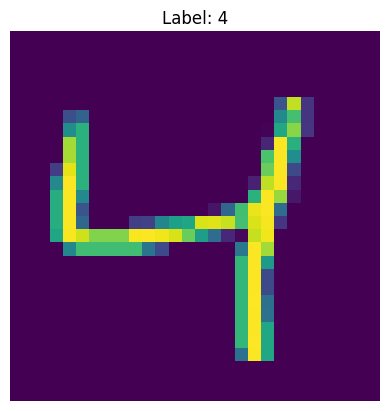

In [28]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [29]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [30]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim -> hidden_dim  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = torch.nn.ReLU()

        # Linear function 2: hidden_dim -> hidden_dim  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim -> hidden_dim  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: hidden_dim -> output_dim  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [31]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True)

#### **ANN 모델 학습**

In [32]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1,28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1,28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs =model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.021506376564502716  Accuracy: 98.1319351196289 %
Iteration: 1000  Loss: 0.005809865891933441  Accuracy: 98.81299591064453 %
Iteration: 1500  Loss: 0.03615370765328407  Accuracy: 99.0075912475586 %
Iteration: 2000  Loss: 0.02768489345908165  Accuracy: 99.143798828125 %
Iteration: 2500  Loss: 0.005106181837618351  Accuracy: 99.33839416503906 %
Iteration: 3000  Loss: 0.0005847583524882793  Accuracy: 99.49406433105469 %
Iteration: 3500  Loss: 0.051924269646406174  Accuracy: 99.35784912109375 %
Iteration: 4000  Loss: 0.004898726008832455  Accuracy: 99.31893157958984 %
Iteration: 4500  Loss: 0.01037273183465004  Accuracy: 99.474609375 %


#### **ANN 학습 결과**

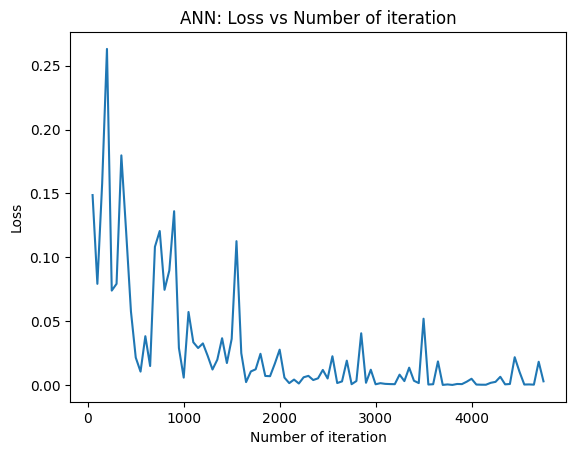

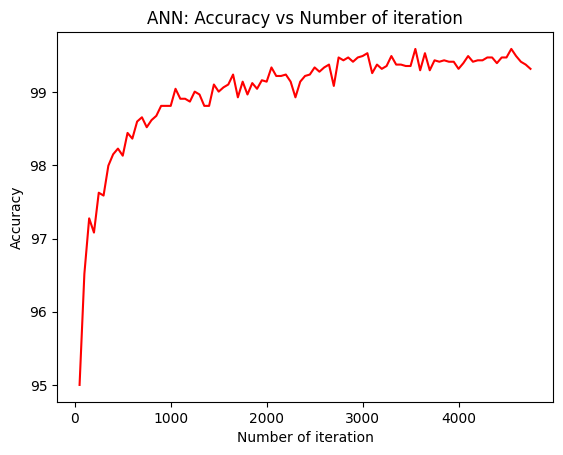

In [33]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

- Loss : 학습 초기(0 ~ 500 iteration)에는 미니배치 단위 업데이트 및 모멘텀의 영향으로 손실값이 최대 약 0.25까지 일시적인 진동을 보였다. 그러나 학습이 진행될수록(1,000 iteration 이후) 진동 폭이 점차 줄어들며 0에 가까운 값(0.01 이하)으로 안정적으로 수렴했다.


- Accuracy :  test에 대한 정확도는 초기 약 96.5%에서 시작하여 약 1,500 iteration 만에 99%에 도달했다. 이후 완만하게 상승하여 후반부(3,000 iteration 이후)에는 약 99.4% ~ 99.5% 이상의 매우 높은 정확도를 꾸준히 유지했다.


- 종합적으로, Loss의 지속적인 감소와 Accuracy의 안정적인 상승 곡선이 잘 맞물려 모델이 과적합이나 발산 없이 0~4 숫자 이미지의 비선형 특징 패턴을 성공적으로 학습했음을 확인할 수 있다.

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [34]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습

hidden_dims = [50, 100, 150, 200]
num_epochs = 5
lr = 0.02

# 결과를 저장할 딕셔너리
results_exp1 = {}

for h_dim in hidden_dims:
    print(f"--- 은닉층 개수: {h_dim} ---")
    model = ANNModel(input_dim=28*28, hidden_dim=h_dim, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)

    loss_list = []
    accuracy_list = []
    iteration_list = []
    count = 0

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            train = images.view(-1, 28*28)

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1

            # 50 iteration마다 평가
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_imgs, test_lbls in test_loader:
                        test = test_imgs.view(-1, 28*28)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_lbls)
                        correct += (predicted == test_lbls).sum().item()

                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)
                iteration_list.append(count)

    results_exp1[h_dim] = {
        'iterations': iteration_list,
        'loss': loss_list,
        'accuracy': accuracy_list
    }

--- 은닉층 개수: 50 ---
--- 은닉층 개수: 100 ---
--- 은닉층 개수: 150 ---
--- 은닉층 개수: 200 ---


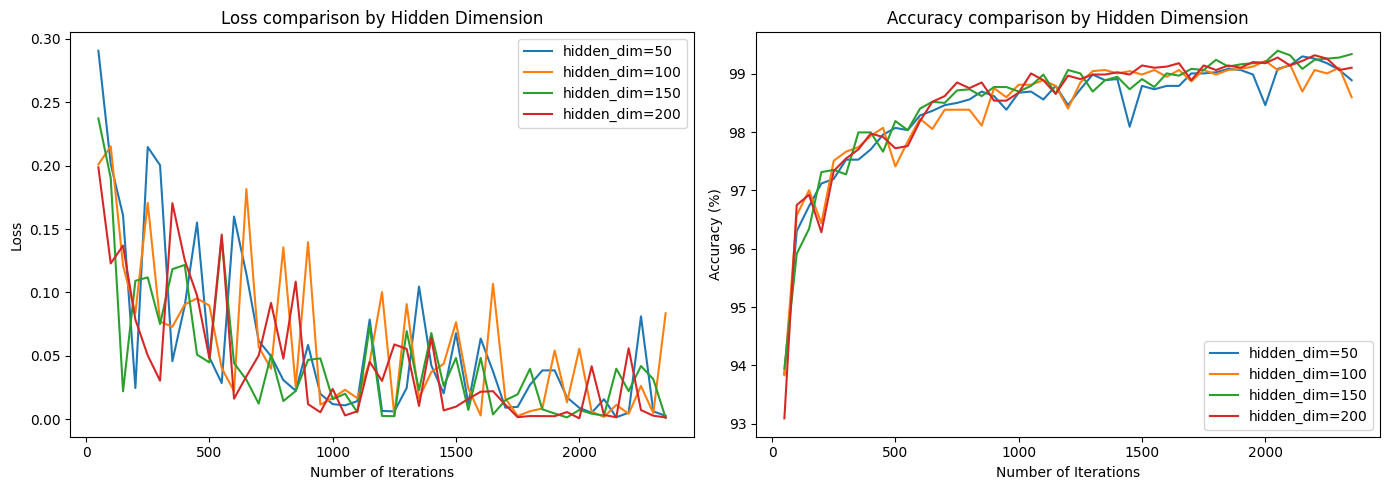

In [35]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(14, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
for h_dim in hidden_dims:
    plt.plot(results_exp1[h_dim]['iterations'], results_exp1[h_dim]['loss'], label=f'hidden_dim={h_dim}')
plt.xlabel("Number of Iterations")
plt.ylabel("Loss")
plt.title("Loss comparison by Hidden Dimension")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
for h_dim in hidden_dims:
    plt.plot(results_exp1[h_dim]['iterations'], results_exp1[h_dim]['accuracy'], label=f'hidden_dim={h_dim}')
plt.xlabel("Number of Iterations")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy comparison by Hidden Dimension")
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- Loss : 모든 은닉층 설정에서 반복이 진행됨에 따라 손실값이 0에 가깝게 수렴했다.은닉층이 50 혹은 100과 같이 차원이 상대적으로 작은 경우, 중반부(500~1000 반복 부근)에서 손실값이 튀는 진동폭이 더 크게 나타났다. 반면 은닉층이 150, 200은 모델의 파라미터 수가 늘어나 표현력이 확장됨에 따라 학습 후반부로 갈수록 손실값이 0.05 이하로 매우 낮고 균일하게 안정화되는 양상을 보였다.


- Accuracy : 초기 500 이내에 네 경우 모두 약 98% 수준까지 빠르게 상승했다. 학습 중후반부를 비교하면 은닉층 150, 200이 99% 이상의 높은 정확도를 안정적으로 유지하며 은닉층 50 대비 전반적으로 우수한 예측 성능을 기록했다. 은닉층 100의 경우 학습 막바지에 일시적으로 정확도가 하락하는 등 불안정성이 일부 관찰되었다.


- 종합적으로 은닉층의 차원이 커질수록 비선형 패턴에 대한 수용력이 높아져 손실 감소와 정확도 안정성에 긍정적인 영향을 미친다.연산량과 성능 사이의 균형을 고려했을 때, 진동 폭이 작고 99% 이상의 최고 성능을 일정하게 유지한 은닉층 150 또는 200이 최적의 하이퍼파라미터라고 생각한다.

In [36]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습

learning_rates = [0.1, 0.05, 0.02, 0.005]
num_epochs = 3
hidden_dim = 200

results_exp2 = {}

for lr in learning_rates:
    print(f"--- 학습률 조정: {lr} ---")
    model = ANNModel(input_dim=28*28, hidden_dim=hidden_dim, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)

    loss_list = []
    accuracy_list = []
    iteration_list = []
    count = 0

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            train = images.view(-1, 28*28)

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_imgs, test_lbls in test_loader:
                        test = test_imgs.view(-1, 28*28)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_lbls)
                        correct += (predicted == test_lbls).sum().item()

                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)
                iteration_list.append(count)

    results_exp2[lr] = {
        'iterations': iteration_list,
        'loss': loss_list,
        'accuracy': accuracy_list
    }

--- 학습률 조정: 0.1 ---
--- 학습률 조정: 0.05 ---
--- 학습률 조정: 0.02 ---
--- 학습률 조정: 0.005 ---


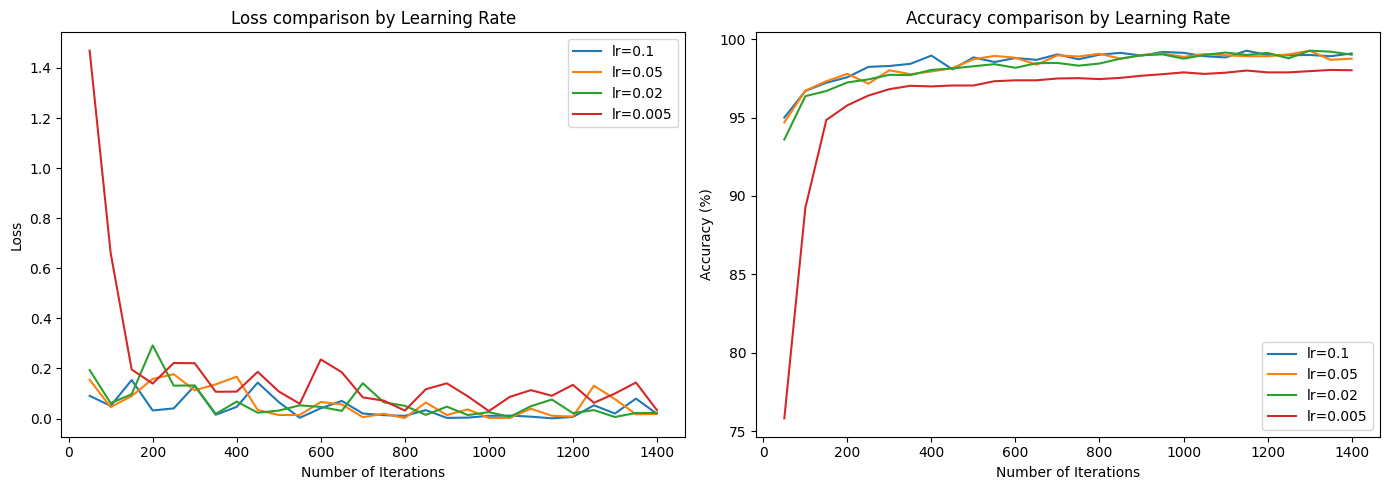

In [37]:
# 실험 2 모델 학습 결과 시각화

plt.figure(figsize=(14, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(results_exp2[lr]['iterations'], results_exp2[lr]['loss'], label=f'lr={lr}')
plt.xlabel("Number of Iterations")
plt.ylabel("Loss")
plt.title("Loss comparison by Learning Rate")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(results_exp2[lr]['iterations'], results_exp2[lr]['accuracy'], label=f'lr={lr}')
plt.xlabel("Number of Iterations")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy comparison by Learning Rate")
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- Loss
  * lr=0.005 : 초반 손실값이 매우 약 1.5로 매우 높게 출발하여 200 반복까지 떨어진 이후에도, 다른 조건들에 비해 전반적인 손실값 레벨이 높고 진동이 늦게까지 지속되는 수렴 지연 현상이 나타났다.
  * lr=0.02, 0.05, 0.1 : 초기부터 손실값이 0.3 이하의 낮은 구간에 빠르게 시작하며, 특히 lr=0.1과 0.05는 600 반복 이후 손실값이 0에 가깝게 빠르게 수렴했다.


- Accuracy
  * lr=0.05 : 시작 정확도가 약 77%로 매우 낮았으며,빠르게 상승하기는 했으나 최종 정확도가 약 98% 수준에 머물러 다른 조건들보다 명확히 낮은 상한선을 보였다.
  * lr=0.02, 0.05, 0.1 : 초기 50 반복에도 이미 95%이상의 높은 정확도로 시작하였으며, 400 반복이후 약 99%까지 완만히 수렴했다. 특히 lr=0.05와 0.1이 가장 가파른 초기 상승률과 높은 최종 수렴치를 달성했다.

- 종합적으로, 학습률이 너무 작으면 가중치 업데이트 보폭이 좁아 주어진 반복 내에 gllobal minimum 부근에 충분히 도달하지 못해 성능이 제한된다. 반면 0.05에서 0.1 수준의 비교적 큰 학습률은 발산하지 않고 손실을 빠르게 줄이며 가장 높은 정확도에 도달했다. 따라서 가장 안정적이면서 빠른 수렴 속도를 보인 lr=0.05 또는 0.1이 최적의 학습률이라 생각한다.

In [38]:
# 실험 3 옵티마이저=[Adagrad, Adadelta, RMSProp, NAG, Adam, Nadam] 로 학습

import torch.optim as optim

optimizers_to_test = ['Adagrad', 'Adadelta', 'RMSProp', 'NAG', 'Adam', 'Nadam']
num_epochs = 10
hidden_dim = 150

# 각 옵티마이저의 결과를 저장할 딕셔너리
results_exp3 = {}

for opt_name in optimizers_to_test:
    print(f"--- Training with Optimizer: {opt_name} ---")

    # 매번 모델을 새롭게 초기화
    model = ANNModel(input_dim=28*28, hidden_dim=hidden_dim, output_dim=5)
    loss_ftn = nn.CrossEntropyLoss()

    # 옵티마이저 (교재 기반 파라미터 설정)
    if opt_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=0.01)
    elif opt_name == 'Adadelta':
        optimizer = optim.Adadelta(model.parameters(), lr=1.0)
    elif opt_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=0.01)
    elif opt_name == 'NAG':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == 'Nadam':
        optimizer = optim.NAdam(model.parameters(), lr=0.002)

    loss_list = []
    accuracy_list = []
    iteration_list = []
    count = 0

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            train = images.view(-1, 28*28)

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1

            # 50 iteration마다 평가
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_imgs, test_lbls in test_loader:
                        test = test_imgs.view(-1, 28*28)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_lbls)
                        correct += (predicted == test_lbls).sum().item()

                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)
                iteration_list.append(count)

    # 실험 결과 저장
    results_exp3[opt_name] = {
        'iterations': iteration_list,
        'loss': loss_list,
        'accuracy': accuracy_list
    }

# ==========================================
# 📊 최종 수치 결과 비교 표 출력
# ==========================================
print("\n" + "="*45)
print(f"{'Optimizer':<12} | {'Final Loss':<10} | {'Final Accuracy'}")
print("-" * 45)
for opt in optimizers_to_test:
    final_loss = results_exp3[opt]['loss'][-1]
    final_acc = results_exp3[opt]['accuracy'][-1]
    print(f"{opt:<12} | {final_loss:<10.4f} | {final_acc:.2f}%")
print("="*45)

--- Training with Optimizer: Adagrad ---
--- Training with Optimizer: Adadelta ---
--- Training with Optimizer: RMSProp ---
--- Training with Optimizer: NAG ---
--- Training with Optimizer: Adam ---
--- Training with Optimizer: Nadam ---

Optimizer    | Final Loss | Final Accuracy
---------------------------------------------
Adagrad      | 0.0003     | 99.34%
Adadelta     | 0.0000     | 99.49%
RMSProp      | 1.6848     | 19.65%
NAG          | 0.0007     | 99.28%
Adam         | 0.0007     | 99.24%
Nadam        | 0.0015     | 99.26%


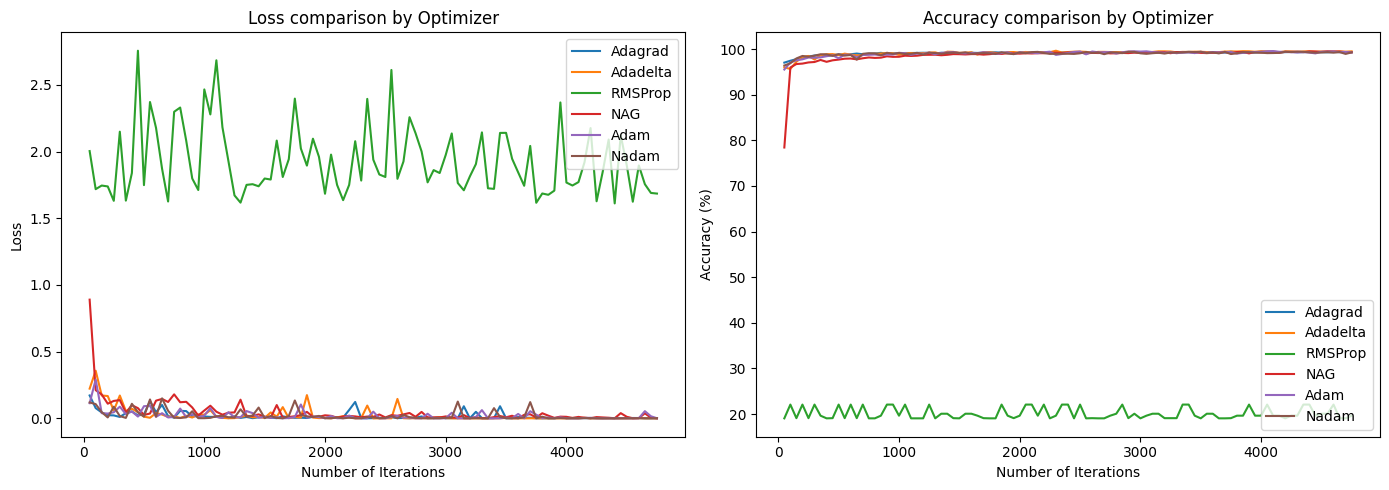

In [39]:
# 실험 3 모델 학습 결과 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
for opt in optimizers_to_test:
    plt.plot(results_exp3[opt]['iterations'], results_exp3[opt]['loss'], label=opt)
plt.xlabel("Number of Iterations")
plt.ylabel("Loss")
plt.title("Loss comparison by Optimizer")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
for opt in optimizers_to_test:
    plt.plot(results_exp3[opt]['iterations'], results_exp3[opt]['accuracy'], label=opt)
plt.xlabel("Number of Iterations")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy comparison by Optimizer")
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**[해석]**

...옵티마이저 간의 성능 비교를 위해서 epoch=10으로 10분을 기다렸는데 너무 충격적인 결과였다. RMSProp의 최종 정확도는 19.65%로, 즉 오지선다에서 무작위로 고를 20%의 확률보다 낮게 나온 것이다. 즉 모델이 전혀 학습하지 못한 것이다.이에 대해 추가적으로 조사해 본 결과 adaptive 옵키마이저와 과도한 학습률이 관련있었다.

일반적인 SGD나 NAG 모델에서 lr=0.01이 적절한 표준 값이지만 RMSProp이나 Adam과 같은 적응형 옵티마이저들은 기울기의 크기에 맞춰 학습 보폭을 자체적으로 매우 민감하게 조절한다고 한다. (파이토치에서 RMSProp과 Adam의 기본 학습률은 0.001) 여기에 교재의 수치인 0.01을 넣자 가중치 업데이트가 너무 커져서 global minmum을 찾지 못하고 발산 현상이 발생한 것이다.


그렇지만 다른 옵티마이저는 왜 살아남았을까?
- Adam(0.001), Nadam(0.002) : 처음부터 적응형 옵티마이저에 맞는 낮은 학습률로 설정되었기 때문에 성공적으로 수렴했다.
- NAG(lr=0.01) : SGD 계열이므로 0.01 수준의 큼직한 학습률도 안정적으로 소화한다.
- Adagrad(lr=0.01) : 가장 흥미로운 비교군이다. Adagrad는 RMSProp과 동일한 0.01로 시작했지만 살아남았다. 그 이유를 예상해보자면 Adagrad의 특성상 과거의 모든 기울기를 누적하여 학습이 진행될수록 강제로 브레이크를 밟아 학습률을 급격히 0에 가깝게 감소시키기 때문입니다. 반면 RMSProp은 지수 이동 평균을 사용하여 예전 기울기를 잊어버리므로 브레이크가 걸리지 않아 끝까지 요동치며 망가진 것입니다.

</n>

한편, 교재의 내용대로 하면 NAG는 그렇다쳐도 Adadelta보다 Adam과 Nadam의 정확도가 높고 손실이 낮을 것이라고 생각하였지만 결과는 이와 일치하지 않았다.(참고로 Nadam은 Adam에 모멘텀 대신 NAG를 추가한 것) 이 세 모델 보두 모멘텀을 적용했다는 공통점에 기반하여 그 이유를 생각해보자.
- **모멘텀의 특징** : 모멘텀 계열은 평탄한 구간이나 안장점을 빠르게 탈출하기 위해 이전 기울기들의 누적 속도를 가중치 업데이트에 반영한다.초반에는 빠르게 굴러떨어지지만, 손실 함수의 아주 좁고 가파른 최솟값 골짜기 바닥에 도달했을 때는 이 누적된 관성이 오히려 방해물이 된다. 즉, 멈춰야 할 때에도 이전 스텝에서 받아온 관성 때문에 최적점을 지나쳐 반대편 경사면으로 튕겨 나가는 오버슈팅이 끊임없이 일어난다. 학습률 스케줄러(lr Decay)가 없으면 관성 항 때문에 최적점 주변에서 진동 폭이 유지되어, 특정 배치에서 Loss가 0.0007~0.0015 수준으로 미세하게 덜 수렴하게 된다.
- **Adadelta**의 감쇠 계수 : 최적점 근처에 수렴하면 최근 가중치의 변화량($D_t$) 자체가 극도로 작아진다.분자에 위치한 이 항 덕분에 학습률 스케줄러를 따로 쓰지 않아도 스스로 보폭을 극도로 미세하게 줄이며 최적점에 멈춘다.
- **MNIST(0~4)의 작은 데이터셋** : 복잡하고 깊은 다층 신경망이나 어려운 데이터셋에서는 모멘텀이 없으면 안장점에 갇혀 학습이 멈춘다. 이 때문에 복잡한 모델에서는 Adam/Nadam이 압도적으로 우세하다. 하지만 이번 실험의 MNIST 0~4 분류는 모델과 데이터가 매우 단순하여 관성이 필요하지 않은 환경이라 생각된다.

또 한편, 발표를 준비하며 RMSProp과 Adadelta가 같은 년도에 발표되었기도 했고 교재에서는 둘을 Adagrad에서 서로 다른 방향으로 개선되었다 했다. 그러나 수식을 공부하면서 Adadelta가 RMSProp의 요소들을 모두 갖고 있어 둘의 성능을 비교해보고 싶었다. 다만 극단적인 RMSProp의 결과가 나오게 되어 아쉬울 따름이다....그리고 lr decay에 대한 개념을 새로 알게 되어 추후 공부해볼 예정이다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2 (self.maxpool 대신 self.maxpool2 사용!)
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out

In [44]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [45]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels  in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        running_loss += loss.item()
        count += 1

        if count % 50 == 0:
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.2086954629364655
Epoch 2, Loss: 0.07563416677379363
Epoch 3, Loss: 0.07139687939757959
Epoch 4, Loss: 0.06424805215019869
Epoch 5, Loss: 0.06280959323253048
Epoch 6, Loss: 0.04963454045892188
Epoch 7, Loss: 0.051064988297224626
Epoch 8, Loss: 0.06530819590333065
Epoch 9, Loss: 0.053988273526879224
Epoch 10, Loss: 0.04452363444277253
Epoch 11, Loss: 0.04981836499495581
Epoch 12, Loss: 0.05097919994749985
Epoch 13, Loss: 0.04602713686621511
Epoch 14, Loss: 0.04531381373668706
Epoch 15, Loss: 0.04611382762908047
Epoch 16, Loss: 0.04352651021935247
Epoch 17, Loss: 0.046084193422472566
Epoch 18, Loss: 0.04372741524210783
Epoch 19, Loss: 0.03766986846512347
Epoch 20, Loss: 0.0388600757204109


#### **CNN 학습 결과**

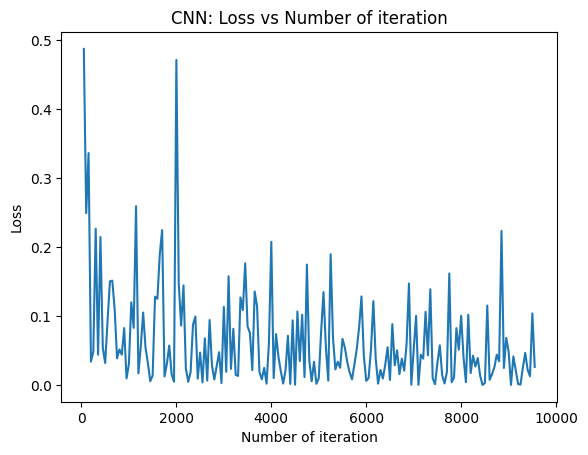

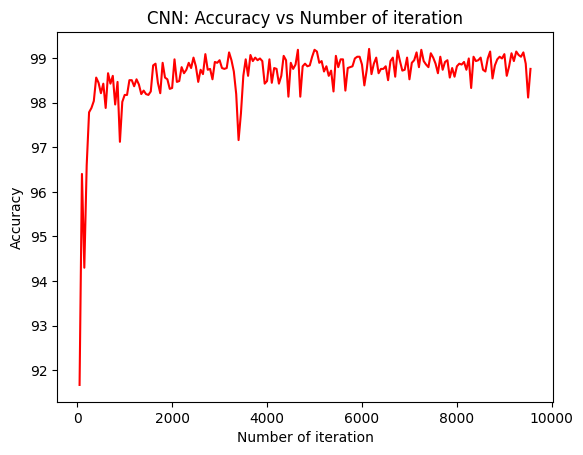

In [46]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
1. 모델 소개
- ANN : 입력 이미지를  1차원 벡터로 평탄화한 뒤, 여러 개의 완전 연결 계층과 활성화 함수를 통과시켜 분류하는 모델이다.
- CNN : 이미지의 2차원 공간 정보를 그대로 유지한 상태에서 커널(필터)을 활용해 지역적 특징(선, 곡선, 경계 등)을 추출하고, 풀링을 통해 다운샘플링하는 이미지 특화 모델이다.
2. 결과 비교
- Loss : ANN은 초반(0~1,000 iteration) 탐색 과정에서 모멘텀/가속 등으로 인한 스파이크가 있었으나, 1,500 iteration 이후 손실값이 0에 가깝게 낮아지며 안정화되었다. / CNN은 전체적으로 손실값이 낮게 형성되지만, 20 에포크(약 9,600 iteration) 동안 학습률 감쇠 없이 미니배치 단위 평가 시 손실값이 튀는 변동성이 후반부까지 이어졌다.
- Accuracy : ANN은 초기 상승률이 CNN에 비해 완만하지만, 학습이 진행될수록 99.4% 이상 대역에 도달하여 안정적으로 우상향하는 곡선을 유지한다. CNN은 이미지 특성을 포착하는 합성곱 계층 덕분에 학습 극초반(0~500 iteration)에 정확도가 매우 가파르게 급상승하며 빠르게 높은 성능 대역에 진입한다.
